Space X Falcon 9 First Stage Landing Prediction

Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch. In this lab, you will create a machine learning pipeline to predict if the first stage will land given the data from the preceding labs.


Perform exploratory Data Analysis and determine Training Labels

    create a column for the class
    Standardize the data
    Split into training data and test data

-Find best Hyperparameter for SVM, Classification Trees and Logistic Regression

    Find the method performs best using test data



In [1]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

In [2]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

In [3]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
data.head(10)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0
5,6,2014-01-06,Falcon 9,3325.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1005,-80.577366,28.561857,0
6,7,2014-04-18,Falcon 9,2296.000000,ISS,CCAFS SLC 40,True Ocean,1,False,False,True,NaN,1.0,0,B1006,-80.577366,28.561857,1
7,8,2014-07-14,Falcon 9,1316.000000,LEO,CCAFS SLC 40,True Ocean,1,False,False,True,NaN,1.0,0,B1007,-80.577366,28.561857,1
8,9,2014-08-05,Falcon 9,4535.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1008,-80.577366,28.561857,0
9,10,2014-09-07,Falcon 9,4428.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1011,-80.577366,28.561857,0


TASK 1

Create a NumPy array from the column Class in data, by applying the method to_numpy() then assign it to the variable Y,make sure the output is a Pandas series (only one bracket df['name of column']).


In [4]:
Y = data['Class'].to_numpy()

TASK 2

Standardize the data in X then reassign it to the variable X using the transform provided below.


In [5]:
# Preprocessing data
# Feature scaling for continuous variables

continious_columns = data.select_dtypes(include = 'float64').columns.tolist()

scaler = preprocessing.StandardScaler()
scaled_features = scaler.fit_transform(data[continious_columns])

# Converting to dataframe

X = pd.DataFrame(scaled_features, columns = scaler.get_feature_names_out(continious_columns))

In [6]:
X

,PayloadMass,Block,Longitude,Latitude
0,-1.948145e-16,-1.575895,0.411430,-0.417073
1,-1.195232e+00,-1.575895,0.411430,-0.417073
2,-1.162673e+00,-1.575895,0.411430,-0.417073
3,-1.200587e+00,-1.575895,-2.433736,2.433637
4,-6.286706e-01,-1.575895,0.411430,-0.417073
...,...,...,...,...
85,1.991005e+00,0.945537,0.409541,-0.395376
86,1.991005e+00,0.945537,0.409541,-0.395376
87,1.991005e+00,0.945537,0.409541,-0.395376
88,1.991005e+00,0.945537,0.411430,-0.417073


TASK 3

Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to 0.2 and random_state to 2. The training data and test data should be assigned to the following labels.

X_train, X_test, Y_train, Y_test


In [7]:
# Splitting data

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size= 0.2, random_state= 2)

TASK 4

Create a logistic regression object then create a GridSearchCV object logreg_cv with cv = 10. Fit the object to find the best parameters from the dictionary parameters.


In [8]:
parameters = {"C": [0.01, 0.1, 1], "penalty": ["l2"], "solver": ["lbfgs"]}
lr = LogisticRegression(max_iter=1000)
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, y_train)
 
print("Tuned hyperparameters:", logreg_cv.best_params_)
print("CV accuracy          :", round(logreg_cv.best_score_, 4))
 

Tuned hyperparameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
CV accuracy          : 0.6964


c:\Users\sfauz\miniconda3\envs\sab_ds\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\sfauz\miniconda3\envs\sab_ds\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\sfauz\miniconda3\envs\sab_ds\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. 

TASK 5

Calculate the accuracy on the test data using the method score:


In [9]:
lr_test_acc = logreg_cv.score(X_test, y_test)
yhat = logreg_cv.predict(X_test)

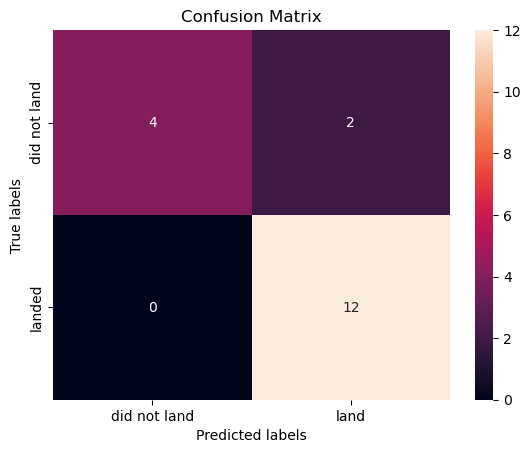

In [10]:
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(y_test,yhat)

TASK 6

Create a support vector machine object then create a GridSearchCV object svm_cv with cv = 10. Fit the object to find the best parameters from the dictionary parameters.


In [12]:
parameters = {
    "kernel": ("linear", "rbf", "poly", "sigmoid"),
    "C": np.logspace(-3, 3, 5),
    "gamma": np.logspace(-3, 3, 5),
}
svm = SVC()
svm_cv = GridSearchCV(svm, parameters, cv=10)

In [13]:
svm_cv.fit(X_train, y_train)

KeyboardInterrupt: 

TASK 7

Calculate the accuracy on the test data using the method score:


In [ ]:
svm_test_acc = svm_cv.score(X_test, Y_test)
print(f"\n[Task 7] SVM test accuracy: {svm_test_acc:.4f}")
 
yhat = svm_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat, "Confusion Matrix – SVM")

TASK 8

Create a decision tree classifier object then create a GridSearchCV object tree_cv with cv = 10. Fit the object to find the best parameters from the dictionary parameters.


In [11]:
parameters = {
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"],
    "max_depth": [2 * n for n in range(1, 10)],
    "max_features": ["sqrt"],          # 'auto' removed in sklearn ≥ 1.2
    "min_samples_leaf": [1, 2, 4],
    "min_samples_split": [2, 5, 10],
}
tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, y_train)
 
print("Tuned hyperparameters:", tree_cv.best_params_)
print("CV accuracy          :", round(tree_cv.best_score_, 4))

Tuned hyperparameters: {'criterion': 'gini', 'max_depth': 14, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'random'}
CV accuracy          : 0.7911


TASK 9

Calculate the accuracy of tree_cv on the test data using the method score:



[Task 9] Decision Tree test accuracy: 0.6667


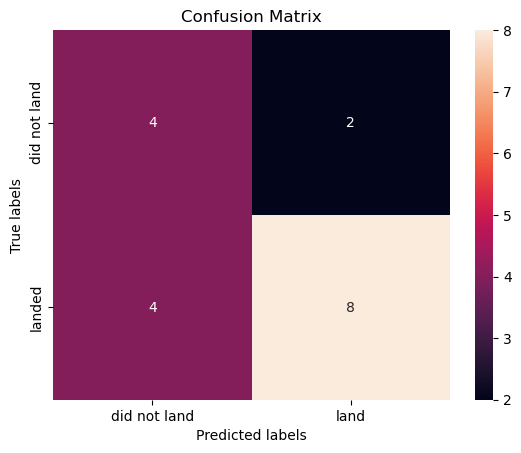

In [12]:
tree_test_acc = tree_cv.score(X_test, y_test)
print(f"\n[Task 9] Decision Tree test accuracy: {tree_test_acc:.4f}")
 
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(y_test, yhat)

TASK 10

Create a k nearest neighbors object then create a GridSearchCV object knn_cv with cv = 10. Fit the object to find the best parameters from the dictionary parameters.


In [14]:
parameters = {
    "n_neighbors": list(range(1, 11)),
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
    "p": [1, 2],
}
KNN = KNeighborsClassifier()
knn_cv = GridSearchCV(KNN, parameters, cv=10)
knn_cv.fit(X_train, y_train)
 
print("Tuned hyperparameters:", knn_cv.best_params_)
print("CV accuracy          :", round(knn_cv.best_score_, 4))

c:\Users\sfauz\miniconda3\envs\sab_ds\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Tuned hyperparameters: {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
CV accuracy          : 0.6946


TASK 11

Calculate the accuracy of knn_cv on the test data using the method score:



[Task 11] KNN test accuracy: 0.8333


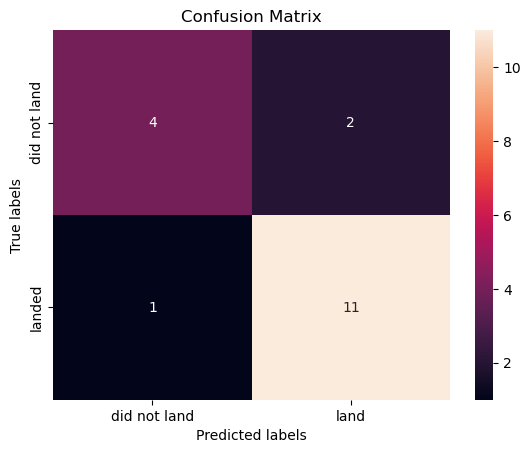

In [18]:
knn_test_acc = knn_cv.score(X_test, y_test)
print(f"\n[Task 11] KNN test accuracy: {knn_test_acc:.4f}")
 
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(y_test, yhat)
 

TASK 12

Find the method performs best:


In [20]:
results = {
    "Logistic Regression": lr_test_acc,
    "Decision Tree":       tree_test_acc,
    "KNN":                 knn_test_acc,
}
 
print("\n[Task 12] Test accuracy comparison:")
for model, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f"  {model:<25} {acc:.4f}")
 
best_model = max(results, key=results.get)
print(f"\n  Best method: {best_model} (accuracy = {results[best_model]:.4f})")


[Task 12] Test accuracy comparison:
  Logistic Regression       0.8889
  KNN                       0.8333
  Decision Tree             0.6667

  Best method: Logistic Regression (accuracy = 0.8889)
